<a href="https://colab.research.google.com/github/sonaliliyanahetti/Final-Year-Research-Malaria-Detection-Models/blob/main/new_Malaria_Detection%2B_Species_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Paths and setup
import os, random, math, shutil, pathlib

DATASET_PATH = "/content/drive/MyDrive/Research/archive/cell_images/cell_images"  # <-- adjust if needed
WORK_DIR = "/content/malaria_subset_4k"
os.makedirs(WORK_DIR, exist_ok=True)

classes = ["Parasitized", "Uninfected"]

# 3. Create 2000-image subset (1000 per class)
files_by_class = {}
SAMPLES_PER_CLASS = 1000  # <-- requested
for cls in classes:
    cls_dir = pathlib.Path(DATASET_PATH) / cls
    files = [str(p) for p in cls_dir.glob("*") if p.suffix.lower() in [".png", ".jpg", ".jpeg"]]
    random.shuffle(files)
    if len(files) < SAMPLES_PER_CLASS:
        raise ValueError(f"Not enough images in {cls}: found {len(files)}, need {SAMPLES_PER_CLASS}")
    files_by_class[cls] = files[:SAMPLES_PER_CLASS]

# Split 70/15/15
splits = {"train": 0.7, "val": 0.15, "test": 0.15}
for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(WORK_DIR, split, cls), exist_ok=True)

for cls in classes:
    files = files_by_class[cls]
    n = len(files)
    n_train = math.floor(n * splits["train"])     # 1400 per class
    n_val   = math.floor(n * splits["val"])       # 300 per class
    train_files = files[:n_train]
    val_files   = files[n_train:n_train+n_val]
    test_files  = files[n_train+n_val:]

    for f in train_files:
        shutil.copy(f, os.path.join(WORK_DIR, "train", cls, os.path.basename(f)))
    for f in val_files:
        shutil.copy(f, os.path.join(WORK_DIR, "val", cls, os.path.basename(f)))
    for f in test_files:
        shutil.copy(f, os.path.join(WORK_DIR, "test", cls, os.path.basename(f)))

print("Subset created at:", WORK_DIR)



Mounted at /content/drive
Subset created at: /content/malaria_subset_4k


In [4]:

import numpy as np
import os, random, math, shutil, pathlib, cv2, warnings
import tensorflow as tf
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [5]:
from sklearn.metrics import (silhouette_score, confusion_matrix,
                              classification_report, roc_curve, auc,
                              precision_recall_curve)

In [6]:


from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from skimage.feature import graycomatrix, graycoprops
from skimage.measure import label, regionprops
warnings.filterwarnings("ignore")
# Species labels (for unsupervised clustering interpretation)
SPECIES_NAMES = {
    0: "P. falciparum",
    1: "P. vivax",
    2: "P. malariae",
    3: "P. ovale",
    4: "P. knowlesi"
}

os.makedirs(WORK_DIR, exist_ok=True)

In [7]:

import pandas as pd

def parasite_inflatter(image_uint8):
    """
    Inflate parasite visibility using CLAHE + morphological dilation.
    Input:  uint8 RGB image [H, W, 3]
    Output: uint8 RGB image [H, W, 3]
    """
    # Step 1: Convert to LAB
    lab = cv2.cvtColor(image_uint8, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    # Step 2: CLAHE on L channel
    # clipLimit=3.0 means don't amplify noise beyond 3x; tileGridSize divides image into 8x8 local regions
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l_enhanced = clahe.apply(l)

    # Step 3: Merge back
    lab_enhanced = cv2.merge([l_enhanced, a, b])
    enhanced_rgb = cv2.cvtColor(lab_enhanced, cv2.COLOR_LAB2RGB)

    # Step 4: Inflate dark (parasite) blobs via morphological dilation
    # Convert to grayscale to find dark blobs
    gray = cv2.cvtColor(enhanced_rgb, cv2.COLOR_RGB2GRAY)
    # Dark regions = parasite candidates
    _, dark_mask = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY_INV)
    # Dilate the mask (inflate blobs by 2 pixels radius)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    inflated_mask = cv2.dilate(dark_mask, kernel, iterations=1)

    # Blend: use inflated mask to slightly darken those regions in the enhanced image
    # This makes parasites stand out more visually
    enhanced_rgb_float = enhanced_rgb.astype(np.float32)
    mask_3ch = np.stack([inflated_mask / 255.0] * 3, axis=-1)
    inflated = (enhanced_rgb_float * (1 - 0.3 * mask_3ch)).clip(0, 255).astype(np.uint8)

    return inflated



In [8]:
def stain_normalize(image_uint8, target_mean=None, target_std=None):
    """
    Normalize Giemsa stain appearance.
    Uses log-OD space to equalize stain intensity across images.
    """
    if target_mean is None:
        target_mean = np.array([148.60, 169.26, 190.44])  # typical Giemsa reference
    if target_std is None:
        target_std  = np.array([41.56, 38.28, 38.16])

    img = image_uint8.astype(np.float32) + 1e-6  # avoid log(0)
    # Per-channel mean/std normalization
    for c in range(3):
        img[:, :, c] = (img[:, :, c] - img[:, :, c].mean()) / (img[:, :, c].std() + 1e-6)
        img[:, :, c] = img[:, :, c] * target_std[c] + target_mean[c]

    return np.clip(img, 0, 255).astype(np.uint8)


In [9]:
def background_suppressor(image_uint8):
    """
    Remove slide background, retain only cell regions.
    """
    gray = cv2.cvtColor(image_uint8, cv2.COLOR_RGB2GRAY)
    # Otsu threshold
    _, cell_mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    # Keep cell region
    result = image_uint8.copy()
    result[cell_mask == 0] = 0
    return result

In [10]:
def full_preprocess(image_tensor):
    """
    Apply: Stain Normalization → Parasite Inflatter → Background Suppressor
    Then normalize to [-1, 1] for the model.
    """
    # Convert float [0,1] tensor to uint8
    img = tf.cast(image_tensor * 255.0, tf.uint8).numpy()

    img = stain_normalize(img)        # Step 1: normalize stain color
    img = parasite_inflatter(img)     # Step 2: inflate parasite visibility
    img = background_suppressor(img)  # Step 3: suppress background

    # Final normalization to [-1, 1] (MobileNet-style, compatible with ViT)
    out = img.astype(np.float32) / 127.5 - 1.0
    return out

def tf_preprocess(x_batch, y_batch):
    """Wrapper for use in tf.data.Dataset.map(), applies full_preprocess to each image in the batch."""
    # Use tf.map_fn to apply the Python function (via tf.py_function) to each image in the batch
    x_out_batch = tf.map_fn(
        fn=lambda single_img: tf.py_function(
            func=full_preprocess,  # full_preprocess expects a single image tensor
            inp=[single_img],
            Tout=tf.float32
        ),
        elems=x_batch, # x_batch is (batch_size, H, W, C)
        fn_output_signature=tf.TensorSpec(shape=[*IMG_SIZE, 3], dtype=tf.float32)
    )
    return x_out_batch, y_batch

In [11]:
# 4. tf.data pipeline
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32  # reduce to 16 if you hit GPU memory limits
AUTOTUNE = tf.data.AUTOTUNE

def make_ds(split):
    ds = tf.keras.utils.image_dataset_from_directory(
        os.path.join(WORK_DIR, split),
        labels="inferred",
        label_mode="binary",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=(split == "train"),
    )
    return ds

train_ds = make_ds("train")
val_ds   = make_ds("val")
test_ds  = make_ds("test")

# Augmentation + preprocessing
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
], name="augment")

def prepare(ds, training=False):
    # Use MobileNetV2 preprocessing (scale to [-1, 1])—works fine for ViT too
    ds = ds.map(lambda x, y: (tf.keras.applications.mobilenet_v2.preprocess_input(x), y),
                num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=AUTOTUNE)
        ds = ds.shuffle(4096)
    return ds.prefetch(AUTOTUNE)

train_ds = prepare(train_ds, training=True)
val_ds   = prepare(val_ds, training=False)
test_ds  = prepare(test_ds, training=False)

Found 1400 files belonging to 2 classes.
Found 300 files belonging to 2 classes.
Found 300 files belonging to 2 classes.


In [12]:
# 5. CNN + ViT hybrid
from tensorflow import keras
from tensorflow.keras import layers

def transformer_block(x, num_heads, mlp_dim, dropout=0.1):
    # LayerNorm + MHA
    x_norm = layers.LayerNormalization(epsilon=1e-6)(x)
    attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=x.shape[-1], dropout=dropout)(x_norm, x_norm)
    x = layers.Add()([x, attn])

    # LayerNorm + MLP
    x_norm = layers.LayerNormalization(epsilon=1e-6)(x)
    mlp = layers.Dense(mlp_dim, activation="gelu")(x_norm)
    mlp = layers.Dropout(dropout)(mlp)
    mlp = layers.Dense(x.shape[-1])(mlp)
    x = layers.Add()([x, mlp])
    return x

def build_cnn_vit(input_shape=(224, 224, 3),
                  cnn_channels=(32, 64, 128),
                  patch_size=16,
                  embed_dim=256,
                  num_transformer_blocks=4,
                  num_heads=8,
                  mlp_dim=512,
                  dropout=0.1):
    inputs = keras.Input(shape=input_shape)

    # CNN stem: downsample and enrich local features
    x = inputs
    for c in cnn_channels:
        x = layers.Conv2D(c, 3, padding="same", activation="relu")(x)
        x = layers.Conv2D(c, 3, padding="same", activation="relu")(x)
        x = layers.MaxPool2D()(x)  # reduces H,W

    # Ensure spatial dims divisible by patch_size
    # Resize feature map to a size divisible by patch_size (tokens grid)
    h, w = x.shape[1], x.shape[2]
    target_h = (h // patch_size) * patch_size
    target_w = (w // patch_size) * patch_size
    x = layers.Resizing(target_h, target_w, interpolation="bilinear")(x)

    # Linear projection of patches (Conv with stride=patch_size acts as patchify+proj)
    x = layers.Conv2D(embed_dim, kernel_size=patch_size, strides=patch_size, padding="valid")(x)  # [B, H', W', D]
    h_tokens, w_tokens = x.shape[1], x.shape[2]
    num_tokens = h_tokens * w_tokens

    # Flatten to tokens
    x = layers.Reshape((num_tokens, embed_dim))(x)

    # Optional positional embedding
    pos_embed = layers.Embedding(input_dim=num_tokens, output_dim=embed_dim)
    positions = tf.range(start=0, limit=num_tokens, delta=1)
    x = x + pos_embed(positions)

    # Transformer encoder
    for _ in range(num_transformer_blocks):
        x = transformer_block(x, num_heads=num_heads, mlp_dim=mlp_dim, dropout=dropout)

    # Token pooling (mean pooling tends to be stable)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.GlobalAveragePooling1D()(x)

    # Classification head
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(mlp_dim, activation="gelu")(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs, name="cnn_vit_hybrid")
    return model

model = build_cnn_vit(
    input_shape=(224, 224, 3),
    cnn_channels=(32, 64, 128),
    patch_size=16,        # tokens grid ~ 7x7 or 8x8 depending on stem
    embed_dim=256,
    num_transformer_blocks=4,
    num_heads=8,
    mlp_dim=512,
    dropout=0.1
)

model.compile(
    optimizer=keras.optimizers.Adam(3e-4),
    loss="binary_crossentropy",
    metrics=[keras.metrics.BinaryAccuracy(name="acc"), keras.metrics.AUC(name="auc")]
)

model.summary()


Model: "cnn_vit_hybrid"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 224, 224,  │        896 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 224, 224,  │      9,248 │ conv2d_7[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 112, 112,  │          0 │ conv2d_8[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 112, 112,  │     36,928 │ conv2d_9[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 56, 56,    │          0 │ conv2d_10[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 56, 56,    │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 56, 56,    │    147,584 │ conv2d_11[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 28, 28,    │          0 │ conv2d_12[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_1          │ (None, 16, 16,    │          0 │ max_pooling2d_5[… │
│ (Resizing)          │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 1, 1, 256) │  8,388,864 │ resizing_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 1, 256)    │          0 │ conv2d_13[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 256)    │          0 │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 1, 256)    │        512 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 256)    │  2,103,552 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1, 256)    │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 256)    │        512 │ add_1[0][0]     

 Total params: 18,278,433 (69.73 MB)

 Trainable params: 18,278,433 (69.73 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# 6. Train
callbacks = [
    keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True, monitor="val_acc"),
    keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5),
]

history = model.fit(train_ds, validation_data=val_ds, epochs=20, callbacks=callbacks)

# 7. Evaluation
test_metrics = model.evaluate(test_ds)
print("Test metrics:", dict(zip(model.metrics_names, test_metrics)))

import numpy as np
y_true = np.concatenate([y for _, y in test_ds], axis=0)
y_pred = np.concatenate([model.predict(x).ravel() for x, _ in test_ds], axis=0)
y_hat = (y_pred >= 0.5).astype(int)
acc = (y_hat == y_true).mean()
print(f"Thresholded test accuracy: {acc:.4f}")

# 8. Save (use Keras native format)
model.save("/content/malaria_model_cnn_vit.keras")



Epoch 1/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - acc: 0.5015 - auc: 0.5093 - loss: 0.8073 - val_acc: 0.5900 - val_auc: 0.6958 - val_loss: 0.6802 - learning_rate: 3.0000e-04
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 171ms/step - acc: 0.5327 - auc: 0.5539 - loss: 0.7024 - val_acc: 0.6633 - val_auc: 0.7203 - val_loss: 0.6429 - learning_rate: 3.0000e-04
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 41s 176ms/step - acc: 0.5694 - auc: 0.6172 - loss: 0.6757 - val_acc: 0.7033 - val_auc: 0.7654 - val_loss: 0.5971 - learning_rate: 3.0000e-04
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 178ms/step - acc: 0.6491 - auc: 0.6932 - loss: 0.6313 - val_acc: 0.8533 - val_auc: 0.9407 - val_loss: 0.3346 - learning_rate: 3.0000e-04
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 171ms/step - acc: 0.9002 - auc: 0.9347 - loss: 0.3207 - val_acc: 0.9467 - val_auc: 0.9828 - val_loss: 0.1774 - learning_rate: 3.0000e-04
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 41s 167ms/step - acc: 0.9392 - auc: 0.9634 - loss: 0.2143 - val_acc: 


=== Classification Report ===
              precision    recall  f1-score   support

 Parasitized       0.92      0.95      0.93       150
  Uninfected       0.94      0.91      0.93       150

    accuracy                           0.93       300
   macro avg       0.93      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300



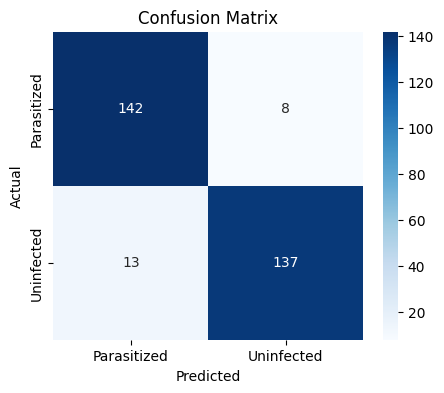

<Figure size 640x480 with 0 Axes>

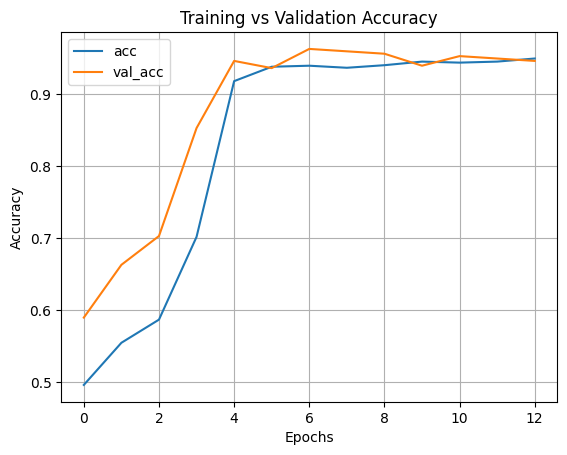

<Figure size 640x480 with 0 Axes>

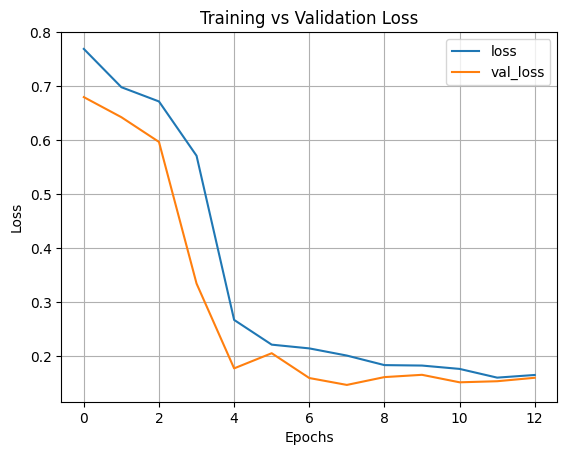

In [18]:
# 9. Visualization (confusion matrix & curves)
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

print("\n=== Classification Report ===")
from sklearn.metrics import classification_report
print(classification_report(y_true, y_hat, target_names=classes))

cm = confusion_matrix(y_true, y_hat)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

history_df = pd.DataFrame(history.history)
plt.figure()
history_df[['acc', 'val_acc']].plot()
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

plt.figure()
history_df[['loss', 'val_loss']].plot()
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.show()



🔬 Extracting features from infected images...
Prediction range: 0.0039555896 0.76707447
Prediction range: 0.0030185347 0.90567833
Prediction range: 0.004198458 0.91548204
Prediction range: 0.0025680927 0.88723433
Prediction range: 0.0034222244 0.91280305
Prediction range: 0.09124135 0.9271637
Prediction range: 0.89402884 0.93157774
Prediction range: 0.092619605 0.9194668
Prediction range: 0.1027916 0.9252332
Prediction range: 0.020175288 0.92207885

🧬 Clustering into 5 species groups...
✅ Silhouette Score: 0.44345036


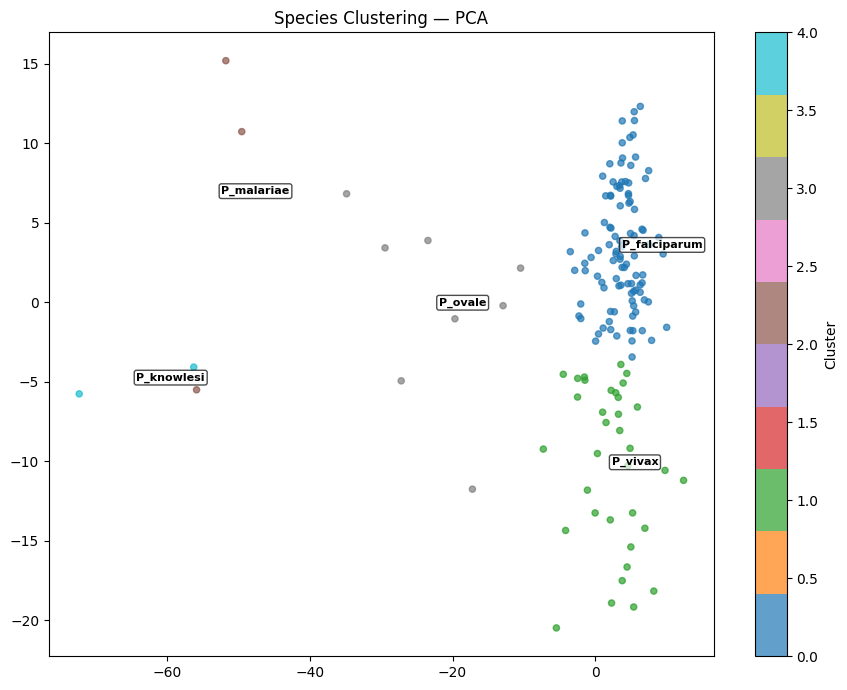

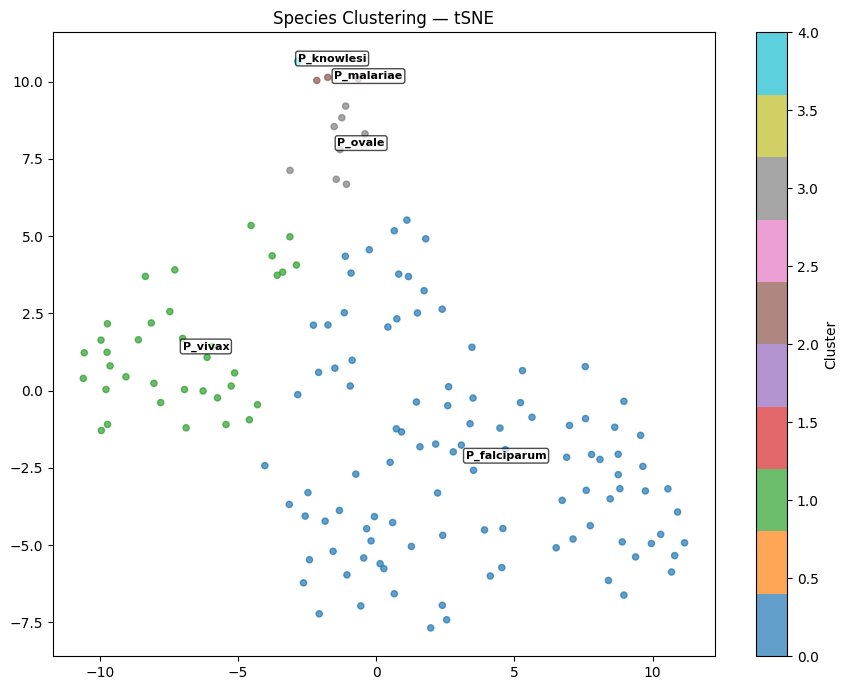

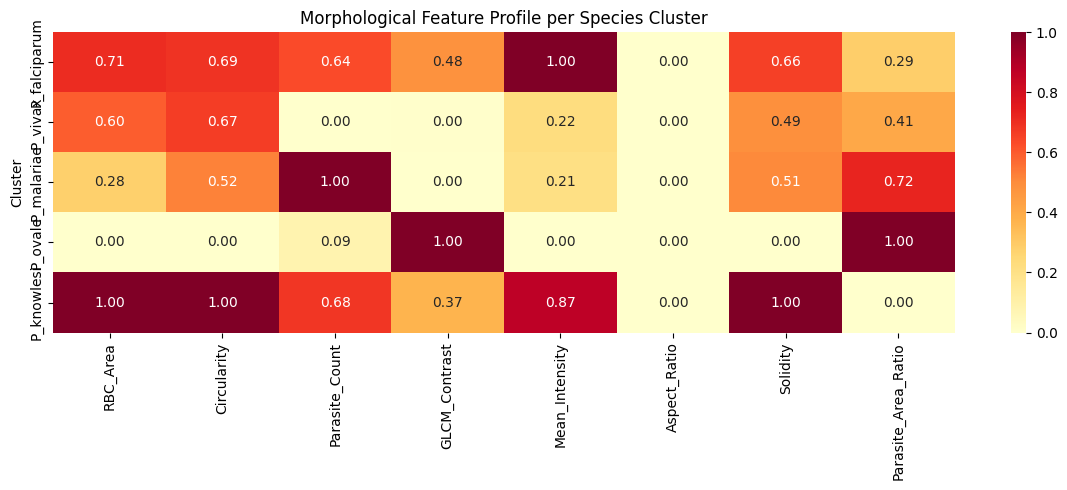

In [17]:

import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
THRESHOLD = 0.30

# ===============================
# FEATURE EXTRACTOR FROM STAGE1
# ===============================
feature_extractor = keras.Model(
    inputs=model.input,
    outputs=model.get_layer("global_average_pooling1d").output,
    name="feature_extractor"
)

# ===============================
# SPECIES NAMES (CLUSTER LABELS)
# ===============================
SPECIES_NAMES = {
    0: "P_falciparum",
    1: "P_vivax",
    2: "P_malariae",
    3: "P_ovale",
    4: "P_knowlesi"
}

# ===============================
# MORPHOLOGICAL FEATURE NAMES
# ===============================
MORPH_NAMES = [
    "RBC_Area",
    "Circularity",
    "Parasite_Count",
    "GLCM_Contrast",
    "Mean_Intensity",
    "Aspect_Ratio",
    "Solidity",
    "Parasite_Area_Ratio"
]

# ===============================
# MORPH FEATURE EXTRACTION
# ===============================
def extract_morph_features(image_tensor):

    img_np = ((image_tensor.numpy() + 1.0) * 127.5).clip(0,255).astype(np.uint8)
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)

    _, thresh = cv2.threshold(gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    contours,_ = cv2.findContours(thresh,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)

    area=0
    circularity=0
    aspect_ratio=0
    solidity=0

    if contours:
        cnt=max(contours,key=cv2.contourArea)
        area=cv2.contourArea(cnt)

        perim=cv2.arcLength(cnt,True)

        if perim>0:
            circularity=4*np.pi*area/(perim**2)

        x,y,w,h=cv2.boundingRect(cnt)
        aspect_ratio=w/(h+1e-6)

        hull_area=cv2.contourArea(cv2.convexHull(cnt))
        solidity=area/(hull_area+1e-6)

    _,para_thresh=cv2.threshold(gray,80,255,cv2.THRESH_BINARY_INV)

    labeled_img=label(para_thresh)

    regions=[r for r in regionprops(labeled_img) if r.area>20]

    parasite_count=len(regions)

    parasite_area_ratio=sum(r.area for r in regions)/(IMG_SIZE[0]*IMG_SIZE[1])

    glcm=graycomatrix(gray,distances=[1],angles=[0],symmetric=True,normed=True)
    contrast=graycoprops(glcm,"contrast")[0,0]

    return np.array([
        area,
        circularity,
        parasite_count,
        contrast,
        np.mean(gray),
        aspect_ratio,
        solidity,
        parasite_area_ratio
    ],dtype=np.float32)


# ===============================
# FEATURE EXTRACTION
# ===============================
print("\n🔬 Extracting features from infected images...")

deep_feats=[]
morph_feats=[]
infected_imgs_store=[]

for x_batch,_ in test_ds:

    preds=model.predict(x_batch,verbose=0).ravel()

    print("Prediction range:",preds.min(),preds.max())

    mask=preds>=THRESHOLD

    if mask.sum()==0:
        continue

    infected_batch=x_batch.numpy()[mask]

    deep_features=feature_extractor.predict(tf.constant(infected_batch),verbose=0)

    deep_feats.append(deep_features)

    for img in infected_batch:
        morph_feats.append(extract_morph_features(tf.constant(img)))

    infected_imgs_store.append(infected_batch)

# ===============================
# SAFETY CHECK
# ===============================
if len(deep_feats)==0:
    raise ValueError(
        "❌ No infected images detected. Lower the threshold or retrain Stage1 model."
    )

deep_feats=np.vstack(deep_feats)

morph_feats=np.array(morph_feats)

infected_imgs_store=np.concatenate(infected_imgs_store,axis=0)

# ===============================
# FEATURE COMBINATION
# ===============================
combined=np.concatenate([deep_feats,morph_feats],axis=1)

combined_scaled=StandardScaler().fit_transform(combined)

# ===============================
# KMEANS CLUSTERING
# ===============================
print("\n🧬 Clustering into 5 species groups...")

kmeans=KMeans(
    n_clusters=5,
    random_state=SEED,
    n_init=10
)

cluster_labels=kmeans.fit_predict(combined_scaled)

sil_score=silhouette_score(combined_scaled,cluster_labels)

print("✅ Silhouette Score:",sil_score)

# ===============================
# CLUSTER PROFILE
# ===============================
profile=pd.DataFrame(morph_feats,columns=MORPH_NAMES)

profile["Cluster"]=cluster_labels

profile=profile.groupby("Cluster").mean()

# ===============================
# PCA VISUALIZATION
# ===============================
pca=PCA(n_components=2)

pca_result=pca.fit_transform(combined_scaled)

plt.figure(figsize=(9,7))

scatter=plt.scatter(
    pca_result[:,0],
    pca_result[:,1],
    c=cluster_labels,
    cmap="tab10",
    alpha=0.7,
    s=20
)

plt.colorbar(scatter,label="Cluster")

for i,name in SPECIES_NAMES.items():

    m=cluster_labels==i

    if m.sum()>0:

        plt.annotate(
            name,
            (pca_result[m,0].mean(),pca_result[m,1].mean()),
            fontsize=8,
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.2",fc="white",alpha=0.7)
        )

plt.title("Species Clustering — PCA")

plt.tight_layout()

plt.savefig("/content/stage2_pca.png",dpi=150)

plt.show()

# ===============================
# TSNE VISUALIZATION
# ===============================
tsne=TSNE(
    n_components=2,
    random_state=SEED
)

tsne_result=tsne.fit_transform(combined_scaled)

plt.figure(figsize=(9,7))

scatter=plt.scatter(
    tsne_result[:,0],
    tsne_result[:,1],
    c=cluster_labels,
    cmap="tab10",
    alpha=0.7,
    s=20
)

plt.colorbar(scatter,label="Cluster")

for i,name in SPECIES_NAMES.items():

    m=cluster_labels==i

    if m.sum()>0:

        plt.annotate(
            name,
            (tsne_result[m,0].mean(),tsne_result[m,1].mean()),
            fontsize=8,
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.2",fc="white",alpha=0.7)
        )

plt.title("Species Clustering — tSNE")

plt.tight_layout()

plt.savefig("/content/stage2_tsne.png",dpi=150)

plt.show()

# ===============================
# MORPHOLOGY HEATMAP
# ===============================
norm_profile=(profile-profile.min())/(profile.max()-profile.min()+1e-6)

plt.figure(figsize=(12,5))

sns.heatmap(
    norm_profile,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    yticklabels=[SPECIES_NAMES[i] for i in range(5)]
)

plt.title("Morphological Feature Profile per Species Cluster")

plt.tight_layout()

plt.savefig("/content/stage2_heatmap.png",dpi=150)

plt.show()